План работы:

1. Реализовать алгоритм двойного Q-обучения для `Taxi-v3`.
2. Выполнить поиск по сетке по параметрам:
   - `gamma`;
   - `alpha`;
   - `epsilon`.
3. Построить графики зависимости **среднего полного вознаграждения**
   от каждого параметра.

Используем две независимые Q-функции:

```text
Q1
Q2
```

На каждом шаге случайно обновляется только одна из них.
Для выбора действия используется сумма:

```text
Q1(s, a) + Q2(s, a)
```

In [1]:
%pip install -q "gymnasium==1.2.3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 24.4 MB/s eta 0:00:00


## Импорты

In [2]:
# Импорты

from itertools import product

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEED = 42

np.random.seed(
    SEED
)


print(
    "Gymnasium:",
    gym.__version__
)

Gymnasium: 1.2.3


## Создание Taxi-v3

In [3]:
# Среда Taxi-v3

ENV_ID = "Taxi-v3"


env = gym.make(
    ENV_ID
)


N_STATES = (
    env.observation_space.n
)

N_ACTIONS = (
    env.action_space.n
)


print(
    "Среда:",
    ENV_ID
)

print(
    "Количество состояний:",
    N_STATES
)

print(
    "Количество действий:",
    N_ACTIONS
)


assert N_STATES == 500
assert N_ACTIONS == 6

Среда: Taxi-v3
Количество состояний: 500
Количество действий: 6


## е-greedy стратегия

Как и в уроке, действие выбирается по `е-greedy`.

С вероятностью:

```text
1 - epsilon
```

берём лучшее действие.

С вероятностью:

```text
epsilon
```

выбираем случайное действие.

In [4]:
# epsilon-greedy

def epsilon_greedy_action(
    q_values,
    epsilon,
    rng,
):

    if rng.random() < epsilon:

        return int(
            rng.integers(
                N_ACTIONS
            )
        )


    return int(
        np.argmax(
            q_values
        )
    )

## Double Q-Learning

Если обновляется `Q1`:

```text
best_action = argmax Q1(s', a')

target =
    r + gamma * Q2(s', best_action)
```

Если обновляется `Q2`:

```text
best_action = argmax Q2(s', a')

target =
    r + gamma * Q1(s', best_action)
```

Таким образом одна таблица выбирает действие,
а вторая оценивает его.

In [5]:
# Double Q-Learning

def train_double_q(
    gamma,
    alpha,
    epsilon,
    n_episodes=2000,
    seed=SEED,
):

    Q1 = np.zeros(
        (
            N_STATES,
            N_ACTIONS,
        ),
        dtype=np.float64,
    )


    Q2 = np.zeros(
        (
            N_STATES,
            N_ACTIONS,
        ),
        dtype=np.float64,
    )


    rng = np.random.default_rng(
        seed
    )


    episode_rewards = []


    for episode in range(
        n_episodes
    ):

        state, info = env.reset(
            seed=(
                seed
                + episode
            )
        )


        total_reward = 0.0


        while True:

            # Для выбора действия
            # объединяем две Q-таблицы.
            action = epsilon_greedy_action(
                Q1[
                    state
                ]
                + Q2[
                    state
                ],
                epsilon,
                rng,
            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(
                action
            )


            done = (
                terminated
                or truncated
            )


            # С вероятностью 0.5
            # обновляем Q1 или Q2.
            if rng.random() < 0.5:

                if done:

                    target = reward

                else:

                    best_next_action = int(
                        np.argmax(
                            Q1[
                                next_state
                            ]
                        )
                    )


                    target = (
                        reward
                        + gamma
                        * Q2[
                            next_state,
                            best_next_action,
                        ]
                    )


                Q1[
                    state,
                    action,
                ] += (
                    alpha
                    * (
                        target
                        - Q1[
                            state,
                            action,
                        ]
                    )
                )


            else:

                if done:

                    target = reward

                else:

                    best_next_action = int(
                        np.argmax(
                            Q2[
                                next_state
                            ]
                        )
                    )


                    target = (
                        reward
                        + gamma
                        * Q1[
                            next_state,
                            best_next_action,
                        ]
                    )


                Q2[
                    state,
                    action,
                ] += (
                    alpha
                    * (
                        target
                        - Q2[
                            state,
                            action,
                        ]
                    )
                )


            total_reward += float(
                reward
            )


            state = next_state


            if done:
                break


        episode_rewards.append(
            total_reward
        )


    return (
        Q1,
        Q2,
        np.asarray(
            episode_rewards,
            dtype=np.float64,
        ),
    )

## Оценка обученной стратегии

После обучения отключаем исследование и используем жадную стратегию:

```text
argmax(Q1 + Q2)
```

Среднее полное вознаграждение считаем на одинаковом наборе
тестовых эпизодов.

In [6]:
# Оценка стратегии

def evaluate_double_q(
    Q1,
    Q2,
    n_episodes=200,
    seed=10000,
):

    rewards = []


    for episode in range(
        n_episodes
    ):

        state, info = env.reset(
            seed=(
                seed
                + episode
            )
        )


        total_reward = 0.0


        while True:

            action = int(
                np.argmax(
                    Q1[
                        state
                    ]
                    + Q2[
                        state
                    ]
                )
            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(
                action
            )


            total_reward += float(
                reward
            )


            state = next_state


            if (
                terminated
                or truncated
            ):
                break


        rewards.append(
            total_reward
        )


    rewards = np.asarray(
        rewards,
        dtype=np.float64,
    )


    return {
        "mean_reward": float(
            rewards.mean()
        ),

        "std_reward": float(
            rewards.std()
        ),

        "rewards": rewards,
    }

## Быстрая проверка алгоритма

До grid search проверим одну комбинацию параметров.

In [7]:
# Проверка Double Q-Learning

Q1_test, Q2_test, train_rewards_test = (
    train_double_q(
        gamma=0.95,
        alpha=0.5,
        epsilon=0.1,
        n_episodes=2000,
        seed=SEED,
    )
)


test_result = evaluate_double_q(
    Q1_test,
    Q2_test,
    n_episodes=200,
)


print(
    "Среднее полное вознаграждение:",
    round(
        test_result[
            "mean_reward"
        ],
        3,
    )
)

print(
    "Стандартное отклонение:",
    round(
        test_result[
            "std_reward"
        ],
        3,
    )
)

Среднее полное вознаграждение: -8.37
Стандартное отклонение: 56.563


## Grid Search

Перебираем полную сетку:

```text
gamma × alpha × epsilon
```

Для каждой комбинации:

1. создаются новые `Q1` и `Q2`;
2. выполняется обучение;
3. агент проверяется на 200 тестовых эпизодах;
4. сохраняется среднее полное вознаграждение.

Сетка содержит `4 × 4 × 4 = 64` комбинации.

In [8]:
# Сетка параметров

GAMMA_VALUES = [
    0.80,
    0.90,
    0.95,
    0.99,
]


ALPHA_VALUES = [
    0.10,
    0.30,
    0.50,
    0.70,
]


EPSILON_VALUES = [
    0.05,
    0.10,
    0.20,
    0.30,
]


GRID_TRAIN_EPISODES = 2000

GRID_TEST_EPISODES = 200


total_combinations = (
    len(
        GAMMA_VALUES
    )
    * len(
        ALPHA_VALUES
    )
    * len(
        EPSILON_VALUES
    )
)


print(
    "Комбинаций:",
    total_combinations
)

Комбинаций: 64


In [9]:
# Поиск по сетке

grid_results = []


combinations = list(
    product(
        GAMMA_VALUES,
        ALPHA_VALUES,
        EPSILON_VALUES,
    )
)


for index, (
    gamma,
    alpha,
    epsilon,
) in enumerate(
    combinations,
    start=1,
):

    Q1, Q2, train_rewards = (
        train_double_q(
            gamma=gamma,
            alpha=alpha,
            epsilon=epsilon,
            n_episodes=(
                GRID_TRAIN_EPISODES
            ),
            seed=SEED,
        )
    )


    evaluation = evaluate_double_q(
        Q1,
        Q2,
        n_episodes=(
            GRID_TEST_EPISODES
        ),
        seed=10000,
    )


    grid_results.append(
        {
            "gamma": gamma,
            "alpha": alpha,
            "epsilon": epsilon,

            "mean_total_reward": (
                evaluation[
                    "mean_reward"
                ]
            ),

            "std_reward": (
                evaluation[
                    "std_reward"
                ]
            ),

            "train_last_200_mean": (
                float(
                    train_rewards[
                        -200:
                    ].mean()
                )
            ),
        }
    )


    print(
        f"{index:02d}/"
        f"{total_combinations} | "
        f"gamma={gamma:.2f} | "
        f"alpha={alpha:.2f} | "
        f"epsilon={epsilon:.2f} | "
        f"reward="
        f"{evaluation['mean_reward']:.2f}"
    )

01/64 | gamma=0.80 | alpha=0.10 | epsilon=0.05 | reward=-163.56
02/64 | gamma=0.80 | alpha=0.10 | epsilon=0.10 | reward=-163.46
03/64 | gamma=0.80 | alpha=0.10 | epsilon=0.20 | reward=-147.18
04/64 | gamma=0.80 | alpha=0.10 | epsilon=0.30 | reward=-158.84
05/64 | gamma=0.80 | alpha=0.30 | epsilon=0.05 | reward=-204.31
06/64 | gamma=0.80 | alpha=0.30 | epsilon=0.10 | reward=-182.94
07/64 | gamma=0.80 | alpha=0.30 | epsilon=0.20 | reward=-173.41
08/64 | gamma=0.80 | alpha=0.30 | epsilon=0.30 | reward=-173.40
09/64 | gamma=0.80 | alpha=0.50 | epsilon=0.05 | reward=-203.11
10/64 | gamma=0.80 | alpha=0.50 | epsilon=0.10 | reward=-174.81
11/64 | gamma=0.80 | alpha=0.50 | epsilon=0.20 | reward=-186.10
12/64 | gamma=0.80 | alpha=0.50 | epsilon=0.30 | reward=-173.62
13/64 | gamma=0.80 | alpha=0.70 | epsilon=0.05 | reward=-191.50
14/64 | gamma=0.80 | alpha=0.70 | epsilon=0.10 | reward=-233.85
15/64 | gamma=0.80 | alpha=0.70 | epsilon=0.20 | reward=-165.84
16/64 | gamma=0.80 | alpha=0.70 | epsilo

## Результаты Grid Search

In [10]:
# Таблица результатов

grid_df = pd.DataFrame(
    grid_results
)


grid_df = grid_df.sort_values(
    "mean_total_reward",
    ascending=False,
).reset_index(
    drop=True
)


display(
    grid_df
)

,gamma,alpha,epsilon,mean_total_reward,std_reward,train_last_200_mean
0,0.99,0.5,0.30,8.165,2.566666,-14.950
1,0.99,0.5,0.20,8.155,2.578948,-5.280
2,0.99,0.7,0.05,8.135,2.626171,5.565
3,0.99,0.7,0.20,8.105,2.616099,-5.340
4,0.99,0.5,0.05,6.900,14.872794,5.175
...,...,...,...,...,...,...
59,0.80,0.3,0.05,-204.315,267.348547,-196.175
60,0.99,0.1,0.10,-225.000,496.697141,-18.675
61,0.95,0.1,0.10,-227.375,493.337860,-24.695
62,0.80,0.7,0.10,-233.855,253.207314,-253.495


In [11]:
# Лучшие параметры

best_row = grid_df.iloc[
    0
]


BEST_GAMMA = float(
    best_row[
        "gamma"
    ]
)

BEST_ALPHA = float(
    best_row[
        "alpha"
    ]
)

BEST_EPSILON = float(
    best_row[
        "epsilon"
    ]
)


print(
    "Лучшие параметры:"
)

print(
    "gamma =",
    BEST_GAMMA
)

print(
    "alpha =",
    BEST_ALPHA
)

print(
    "epsilon =",
    BEST_EPSILON
)

print(
    "Среднее полное вознаграждение =",
    round(
        float(
            best_row[
                "mean_total_reward"
            ]
        ),
        3,
    )
)

Лучшие параметры:
gamma = 0.99
alpha = 0.5
epsilon = 0.3
Среднее полное вознаграждение = 8.165


## Подготовка данных для графиков

Поскольку grid search проверяет все комбинации одновременно,
для зависимости от одного параметра усредняем результат
по всем значениям двух остальных параметров.

Например, для `gamma = 0.9` берём среднее вознаграждение
всех комбинаций с этим `gamma`.

In [12]:
# Средние значения по параметрам

gamma_plot = (
    grid_df
    .groupby(
        "gamma",
        as_index=False,
    )[
        "mean_total_reward"
    ]
    .mean()
)


alpha_plot = (
    grid_df
    .groupby(
        "alpha",
        as_index=False,
    )[
        "mean_total_reward"
    ]
    .mean()
)


epsilon_plot = (
    grid_df
    .groupby(
        "epsilon",
        as_index=False,
    )[
        "mean_total_reward"
    ]
    .mean()
)


display(
    gamma_plot
)

display(
    alpha_plot
)

display(
    epsilon_plot
)

,gamma,mean_total_reward
0,0.80,-178.449062
1,0.90,-103.740938
2,0.95,-41.462812
3,0.99,-43.841563


,alpha,mean_total_reward
0,0.1,-157.972813
1,0.3,-61.252813
2,0.5,-67.229375
3,0.7,-81.039375


,epsilon,mean_total_reward
0,0.05,-107.970000
1,0.10,-104.724375
2,0.20,-81.393750
3,0.30,-73.406250


## График: среднее полное вознаграждение от gamma

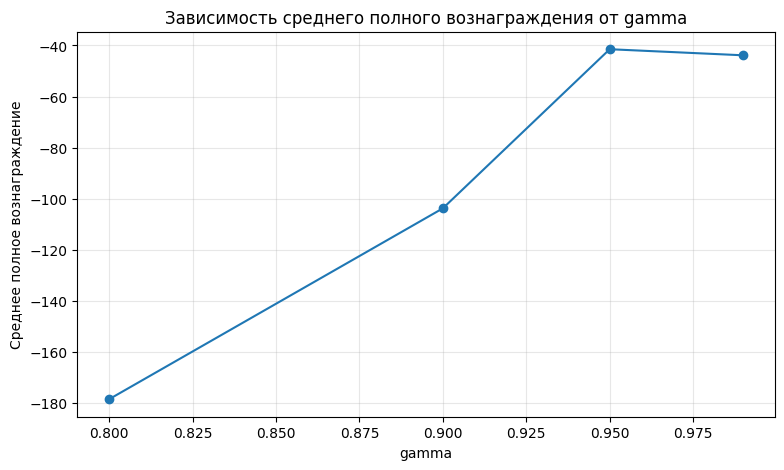

In [13]:
# Reward от gamma

plt.figure(
    figsize=(
        9,
        5,
    )
)


plt.plot(
    gamma_plot[
        "gamma"
    ],
    gamma_plot[
        "mean_total_reward"
    ],
    marker="o",
)


plt.xlabel(
    "gamma"
)

plt.ylabel(
    "Среднее полное вознаграждение"
)

plt.title(
    "Зависимость среднего полного "
    "вознаграждения от gamma"
)

plt.grid(
    alpha=0.3
)

plt.show()

## График: среднее полное вознаграждение от alpha

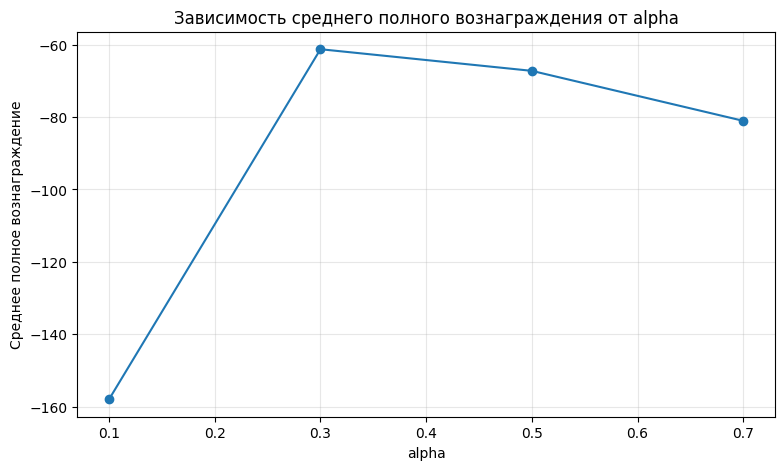

In [14]:
# Reward от alpha

plt.figure(
    figsize=(
        9,
        5,
    )
)


plt.plot(
    alpha_plot[
        "alpha"
    ],
    alpha_plot[
        "mean_total_reward"
    ],
    marker="o",
)


plt.xlabel(
    "alpha"
)

plt.ylabel(
    "Среднее полное вознаграждение"
)

plt.title(
    "Зависимость среднего полного "
    "вознаграждения от alpha"
)

plt.grid(
    alpha=0.3
)

plt.show()

## График: среднее полное вознаграждение от epsilon

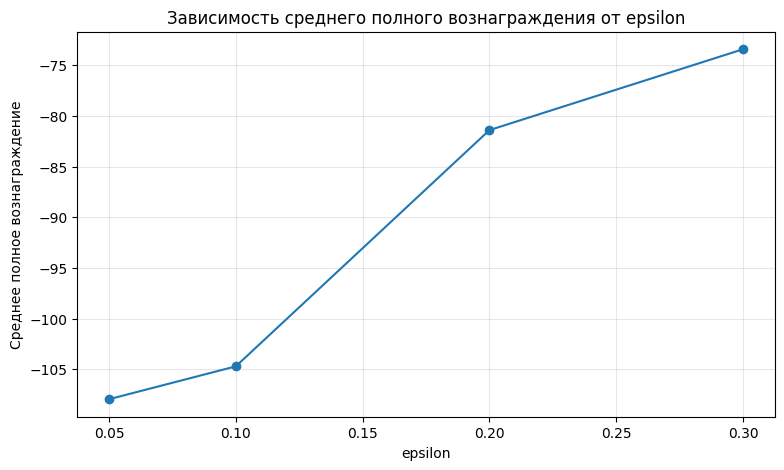

In [15]:
# Reward от epsilon

plt.figure(
    figsize=(
        9,
        5,
    )
)


plt.plot(
    epsilon_plot[
        "epsilon"
    ],
    epsilon_plot[
        "mean_total_reward"
    ],
    marker="o",
)


plt.xlabel(
    "epsilon"
)

plt.ylabel(
    "Среднее полное вознаграждение"
)

plt.title(
    "Зависимость среднего полного "
    "вознаграждения от epsilon"
)

plt.grid(
    alpha=0.3
)

plt.show()

## Обучение с лучшими параметрами

Теперь ещё раз обучаем Double Q-Learning уже с найденными
лучшими параметрами и смотрим динамику полного вознаграждения.

In [16]:
# Финальное обучение

FINAL_EPISODES = 5000


Q1_best, Q2_best, final_rewards = (
    train_double_q(
        gamma=BEST_GAMMA,
        alpha=BEST_ALPHA,
        epsilon=BEST_EPSILON,
        n_episodes=FINAL_EPISODES,
        seed=123,
    )
)

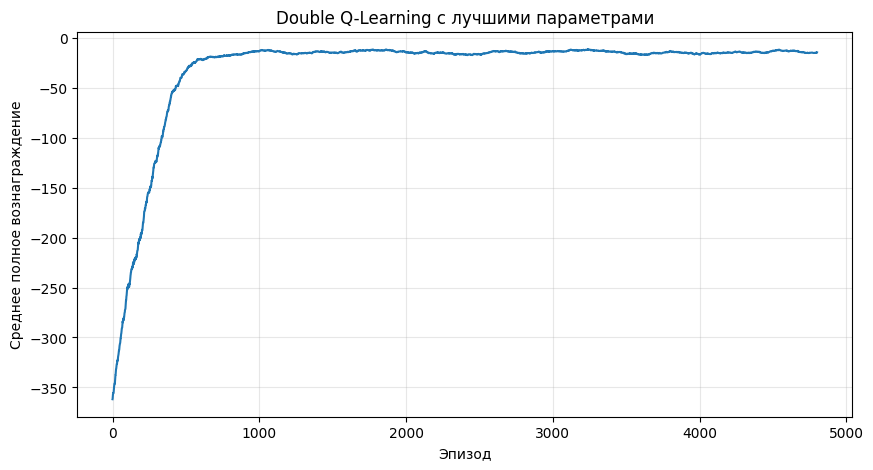

In [17]:
# Скользящее среднее

WINDOW = 200


moving_average = np.convolve(
    final_rewards,
    np.ones(
        WINDOW
    ) / WINDOW,
    mode="valid",
)


plt.figure(
    figsize=(
        10,
        5,
    )
)


plt.plot(
    moving_average
)


plt.xlabel(
    "Эпизод"
)

plt.ylabel(
    "Среднее полное вознаграждение"
)

plt.title(
    "Double Q-Learning "
    "с лучшими параметрами"
)

plt.grid(
    alpha=0.3
)

plt.show()

## Финальная проверка

In [18]:
# Финальная оценка

final_evaluation = evaluate_double_q(
    Q1_best,
    Q2_best,
    n_episodes=500,
    seed=20000,
)


print(
    "Среднее полное вознаграждение:",
    round(
        final_evaluation[
            "mean_reward"
        ],
        3,
    )
)

print(
    "Стандартное отклонение:",
    round(
        final_evaluation[
            "std_reward"
        ],
        3,
    )
)

Среднее полное вознаграждение: 7.786
Стандартное отклонение: 2.599


## Результат

В работе реализован алгоритм **Double Q-Learning** для среды `Taxi-v3`.

В отличие от обычного Q-learning используются две независимые таблицы:

```text
Q1
Q2
```

При обновлении `Q1` действие в следующем состоянии выбирается по `Q1`,
но оценивается при помощи `Q2`. При обновлении `Q2` выполняется обратная
операция. Это позволяет уменьшить переоценку Q-значений.

Для подбора гиперпараметров выполнен полный grid search по:

```text
gamma
alpha
epsilon
```

Для каждой комбинации агент обучается заново, после чего оценивается
на одинаковых тестовых эпизодах.

Построены три графика зависимости:

```text
Среднее полное вознаграждение - gamma
Среднее полное вознаграждение - alpha
Среднее полное вознаграждение - epsilon
```

Также автоматически определяется лучшая комбинация параметров,
после чего с ней выполняется финальное обучение и проверка модели.